In [1]:
import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import torch 
import torchvision

from tqdm import tqdm
from mindquantum.algorithm.library import amplitude_encoder

project_path = pathlib.Path.cwd().parent.parent.parent



In [8]:
def generate_dataset(datasets_dir=project_path/"raw_datasets", num_samples_per_class=2000, img_size=16):
    """
    Creates a subset of MNIST dataset containing only classes 0,3,6,1,4,7
    
    Args:
        datasets_dir: Directory to store/load the MNIST dataset
        num_samples_per_class: Number of samples to extract per class
        img_size: Size to resize the images to (img_size x img_size)
        
    Returns:
        x_train: Training data with shape (num_samples, features)
        y_train: Training labels
        x_test: Test data with shape (test_samples, features)
        y_test: Test labels
    """
    # Define the transformations
    transform = torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Resize((img_size, img_size)),
    ])
    
    # Define the classes to extract
    selected_classes = [0, 3, 6, 1, 4, 7]
    
    # Load MNIST training dataset
    full_train_dataset = torchvision.datasets.MNIST(datasets_dir, train=True, download=True, transform=transform)
    
    # Extract indices for selected classes
    train_indices = []
    for class_idx in selected_classes:
        class_indices = (full_train_dataset.targets == class_idx).nonzero().squeeze()
        selected_indices = class_indices[:num_samples_per_class]  # Take first N samples of each class
        train_indices.append(selected_indices)
    train_indices = torch.cat(train_indices)
    
    # Shuffle the indices
    shuffled_train_indices = train_indices[torch.randperm(len(train_indices))]
    
    # Get training data and labels
    x_train = np.array([full_train_dataset[i.item()][0].numpy().reshape(-1) for i in shuffled_train_indices])
    y_train = np.array([full_train_dataset[i.item()][1] for i in shuffled_train_indices])
    
    # Do the same for test dataset
    full_test_dataset = torchvision.datasets.MNIST(datasets_dir, train=False, download=True, transform=transform)
    
    test_indices = []
    for class_idx in selected_classes:
        class_indices = (full_test_dataset.targets == class_idx).nonzero().squeeze()
        test_indices.append(class_indices)
    test_indices = torch.cat(test_indices)
    
    # Shuffle the test indices
    shuffled_test_indices = test_indices[torch.randperm(len(test_indices))]
    
    # Get test data and labels
    x_test = np.array([full_test_dataset[i.item()][0].numpy().reshape(-1) for i in shuffled_test_indices])
    y_test = np.array([full_test_dataset[i.item()][1] for i in shuffled_test_indices])

    return x_train, y_train, x_test, y_test


In [9]:
img_size = 16 
num_samples_per_class = 2000


In [10]:
x_train, y_train, x_test, y_test = generate_dataset(num_samples_per_class=num_samples_per_class,img_size=img_size)

100%|██████████| 9.91M/9.91M [00:09<00:00, 1.04MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 258kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 740kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.59MB/s]


In [11]:
def data_to_amplitude_params(x):
    _,paramsSolver = amplitude_encoder(x,n_qubits=8)
    return np.array(paramsSolver.params_value)



In [12]:

x_train_params = []
for i in tqdm(range(len(x_train))):
    params = data_to_amplitude_params(x_train[i])
    x_train_params.append(params)
x_train_params = np.array(x_train_params)

100%|██████████| 12000/12000 [07:02<00:00, 28.43it/s]


In [13]:
x_test_params = []
for i in tqdm(range(len(x_test))):
    params = data_to_amplitude_params(x_test[i])
    x_test_params.append(params)
x_test_params = np.array(x_test_params)

100%|██████████| 6093/6093 [05:41<00:00, 17.86it/s]


Training set shape: (12000, 256)
Training labels shape: (12000,)
Test set shape: (6093, 256)
Test labels shape: (6093,)


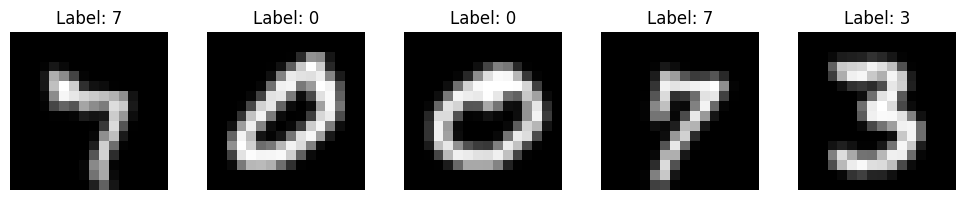

In [14]:


print("Training set shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test set shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

# Display sample images
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i].reshape(16,16), cmap='gray')
    plt.title(f'Label: {y_train[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()



In [15]:
def save_dataset(x_train, y_train, x_test, y_test, n_qubits, data_type, datasets_path):
    os.makedirs(f"{datasets_path}/{data_type}", exist_ok=True)
    n_layers = 0
    n_train_samples = len(y_train)
    n_test_samples = len(y_test)

    np.save(f"{datasets_path}/{data_type}/x_train_qubit_{n_qubits}_layer_{n_layers}_samples_{n_train_samples}.npy", x_train)
    np.save(f"{datasets_path}/{data_type}/y_train_qubit_{n_qubits}_layer_{n_layers}_samples_{n_train_samples}.npy", y_train)
    np.save(f"{datasets_path}/{data_type}/x_test_qubit_{n_qubits}_layer_{n_layers}_samples_{n_test_samples}.npy", x_test)
    np.save(f"{datasets_path}/{data_type}/y_test_qubit_{n_qubits}_layer_{n_layers}_samples_{n_test_samples}.npy", y_test)

In [16]:
n_qubits = 8
data_type = 'mnist_036147'
datasets_path = project_path/'datasets'
save_dataset(x_train_params,y_train,x_test_params,y_test,n_qubits,data_type,datasets_path)
